# The Potential of the "U"
### Solving the Generalized Poisson Equation with a Complex Dielectric

*University of Utah — Department of Chemical Engineering*

## 1. Governing Equation

The electric potential $V$ in a linear, isotropic, source-free dielectric medium satisfies the **generalized Poisson equation**:

$$\nabla \cdot (\varepsilon_c \nabla V) = \frac{\rho}{\varepsilon_0}$$

where $\rho$ is the free charge density, $\varepsilon_0 = 8.854 \times 10^{-12}$ F/m is the permittivity of free space, and $\varepsilon_c$ is the **complex permittivity** of the medium.

For this problem there are no free charges in the bulk ($\rho = 0$), so the equation reduces to:

$$\nabla \cdot (\varepsilon_c \nabla V) = 0$$

### Complex Permittivity

The U logo is modelled as a **lossy dielectric** with complex permittivity:

$$\varepsilon_c = \varepsilon_r + \frac{\sigma}{j\omega\varepsilon_0} = 1.5 - 3j$$

where $\varepsilon_r = 1.5$ is the relative permittivity and the imaginary part encodes ohmic losses through the conductivity $\sigma$. The background medium is free space: $\varepsilon_c = 1.0$.

The electric field is recovered from the potential as $\mathbf{E} = -\nabla V$.

## 2. Splitting into Real and Imaginary Parts

Since $\varepsilon_c$ and $V$ are both complex, we write $V = V_r + jV_i$ and split the governing equation into two coupled real PDEs. Substituting and separating real and imaginary parts:

$$\nabla \cdot (\varepsilon_r \nabla V_r) - \nabla \cdot (\varepsilon_i \nabla V_i) = 0 \qquad [\text{Re}]$$

$$\nabla \cdot (\varepsilon_r \nabla V_i) + \nabla \cdot (\varepsilon_i \nabla V_r) = 0 \qquad [\text{Im}]$$

where $\varepsilon_r = \text{Re}(\varepsilon_c)$ and $\varepsilon_i = \text{Im}(\varepsilon_c)$. This is a linear coupled system in $V_r$ and $V_i$ that uPDE solves directly using sparse matrix methods.

## 3. Boundary Conditions

The domain is a unit square $[0,1]\times[0,1]$ with the U logo centered inside, padded by 15% on all sides.

| Side | $V_r$ | $V_i$ |
|------|-------|-------|
| Left  | $V_r = +1$ V (Dirichlet) | $V_i = 0$ (Dirichlet) |
| Right | $V_r = -1$ V (Dirichlet) | $V_i = 0$ (Dirichlet) |
| Top   | $\partial V_r/\partial n = 0$ (Neumann) | $\partial V_i/\partial n = 0$ (Neumann) |
| Bottom| $\partial V_r/\partial n = 0$ (Neumann) | $\partial V_i/\partial n = 0$ (Neumann) |

The applied voltage is real ($V_i = 0$ at the electrodes), consistent with a DC or low-frequency sinusoidal excitation where the phase reference is set by the left electrode.

## 4. Electric Field Intensity

With a complex potential $V = V_r + jV_i$, the complex electric field is:

$$\mathbf{E} = -\nabla V = -(\nabla V_r + j\nabla V_i)$$

The physical field intensity (magnitude of the phasor) is:

$$|\mathbf{E}| = \sqrt{|\nabla V_r|^2 + |\nabla V_i|^2} = \sqrt{\left(\frac{\partial V_r}{\partial x}\right)^2 + \left(\frac{\partial V_i}{\partial x}\right)^2 + \left(\frac{\partial V_r}{\partial y}\right)^2 + \left(\frac{\partial V_i}{\partial y}\right)^2}$$

The gradient is computed using **interface-aware one-sided differences** at the U boundary to avoid artificial smearing of the field discontinuity across the dielectric interface.

## 5. Solution

In [1]:
import base64, zlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
from scipy.ndimage import zoom
from upde import PDE, PDESystem

### 5.1 Configuration

In [2]:
# ── Grid and domain ──────────────────────────────────────────────────────
nx, ny      = 200, 200    # grid resolution
Lx, Ly      = 1.0, 1.0   # physical domain size [m]
pad_frac    = 0.15        # padding around the U as fraction of domain

# ── Applied voltage ───────────────────────────────────────────────────────
V_left      =  1.0        # left  electrode [V]
V_right     = -1.0        # right electrode [V]

# ── Complex permittivity ──────────────────────────────────────────────────
#   Background:  eps_c = 1.0 + 0j  (free space)
#   U logo:      eps_c = 1.5 - 3j  (lossy dielectric)
eps_r_back  =  1.0
eps_i_back  =  0.0
eps_r_U     =  1.5
eps_i_U     = -3.0

### 5.2 U Logo Mask

The U shape is extracted pixel-exact from the official University of Utah SVG logo, stored as a compressed binary mask and resampled to the chosen grid resolution at runtime.

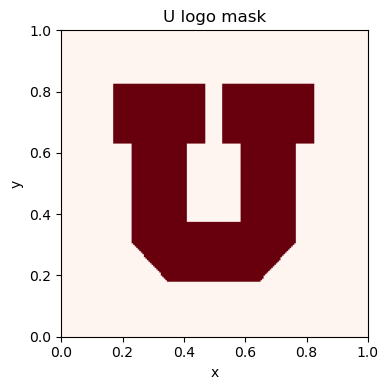

In [3]:
_MASK_SHAPE = (1004, 1094)
_MASK_B64 = (
    "eNrt271t41AQhVEJDBS6BJbi0uzSthSXwPAFhL3JLuBE8PuZIQbGmQLoC+r4y3i7Oeecc84555xz"
    "zjn3716/Zu/j21Pepp/y5/8jvtYfcbvd55/y/u8R2/wjvr2Qx/RDPv8/4mX6Eee3Ifv0U9o6kSOE"
    "yAciiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIII"
    "IogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKI"
    "IIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCCCCKIIIIIIogggggiiCCC"
    "CCKIIIIIIogggggiv4nIbej9nrcf7z73x7/fNubzyT0GfD65lyGfz27v9/nsXod8Pru3fp/PDhFE"
    "EEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBB"
    "BBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQR"
    "RBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQ"
    "QQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEE"
    "EUQQQQQRRBBBBBFEfhWRryuIxFwAkZgLIBJzAURCDhFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQR"
    "RBBBBBFEEEEEEUQQQQQRRBBBBBFEEEEEEUQQQQQRRBBBJJXIftGOH7+Tei3yy3R8NhZztyL/ND/9"
    "z/R8vxZyP344thWpWc+HdBH38yd9LzUiclVGOj62fK0RkasyEvKN4xURuSojHV+fbjUiclFGOr4L"
    "viYj7x1D9hoRuSYjHz1D3mpE5JKMtJ4d9xoRuSQjn12/zKNGRC7JyHvXkL1GRK7IyEffkLcaEbkg"
    "I61vx70I1fyMdFLNz0gn1fyMdO5Iz0jrHZKdkT+9Q5Iz8tm7IzsjR++Oe42IpGfk7P5lHjUikp6R"
    "7h3JGWn9Q15rRCQ5I/0RSc7I0b/jXiMiyRk5B36ZR42IJGdkYEdqRtrIkNcaEUnNyEhEUjNyjOy4"
    "14hIakbOoV/mUSMiqRm5FRnSxobsNSKS2LOxiCT27BgcUiMiiT07B1/IViMiiT0b3JGWkTY6ZK8R"
    "kbSMjEYkLSPH8JAaEUnLyDn8QrYaEUnLyPCOpIy08SF7jYgkZWQ8IkkZOSaG1IhIUkbOiRey1YhI"
    "UkYmdqRkpM0M2WtEJCUjMxFJycgxNaRGRFIyck69kK1GRFIyMrUjISNtbsheIyIJGZmLSEJGjskh"
    "NSKSkJFz8oVsNSKSkJHJHeEZabND9hoRCc/IbETCM3JMD6kRkfCMnNMvZKsRkfCMTO8IzkibH7LX"
    "iEhwRuYjEpyRY2FIjYgEZ+RceCFbjYgEZ2RhR2hG2sqQvUZEQjOyEpHQjBxLQ2pEJDQj59IL2WpE"
    "JDQjSzsCM9LWhuw1IhKYkbWIBGbkWBxSIyKBGTkXX8hWIyKBGVncEZaRtjpkrxGRsIysRiQsI8fy"
    "kBoRCcvIufxCthoRCcvI8o6gjLT1IXuNiARlZD0iQRk5AobUiEhQRs6AF7LViEhQRgJ2hGSkRQzZ"
    "a0QkJCMREQnJyBEypEZEQjJyhryQrUZEQjISsiMgIy1myF4jIgEZiYlIQEaOoCE1IhKQkTPohWw1"
    "IhKQkaAdyxlpUUP2GhFZzkhURJYzcoQNqRGR5YycYS9kqxGR5YyE7VjMSIsbsteIyGJG4iKymJEj"
    "cEiNiCxm5Ax8IVuNiCxmJHDHUkZa5JC9RkSWMhIZkaWMHKFDakRkKSNn6AvZakRkKSM355xzzjnn"
    "nHPOOeec+433F2wQf4s="
)

def load_U_mask(nx, ny, pad_frac=0.15):
    """Decode mask, embed with padding, return bool array [ix, iy]."""
    raw      = zlib.decompress(base64.b64decode(_MASK_B64))
    bits     = np.unpackbits(np.frombuffer(raw, dtype=np.uint8))
    H, W     = _MASK_SHAPE
    mask_img = bits[:H * W].reshape(H, W).astype(np.float32)
    u_ny = int(round(ny * (1.0 - 2 * pad_frac)))
    u_nx = int(round(nx * (1.0 - 2 * pad_frac)))
    resampled = zoom(mask_img, (u_ny / H, u_nx / W), order=1) > 0.3
    canvas = np.zeros((ny, nx), dtype=bool)
    pad_iy = int(round(ny * pad_frac))
    pad_ix = int(round(nx * pad_frac))
    canvas[pad_iy:pad_iy + u_ny, pad_ix:pad_ix + u_nx] = resampled
    return canvas.T[:, ::-1]   # [ix, iy], y=0 at bottom

# Preview the mask
U_mask_preview = load_U_mask(200, 200)
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(U_mask_preview.T[::-1, :], cmap='Reds', origin='upper',
          extent=[0, 1, 0, 1], aspect='equal')
ax.set_title('U logo mask')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

### 5.3 Interface-Aware Gradient

Standard central differences smear the field gradient across the dielectric interface, producing a spurious double-edge artifact. At cells bordering the U boundary we replace the central-difference stencil with a one-sided stencil that stays on the same side of the interface.

In [4]:
def interface_gradient_2d(V, dx, dy, mask):
    """
    Gradient of V with one-sided differences at dielectric interfaces.
    Eliminates the two-cell smearing artifact at the eps_c jump.

    mask : bool array [nx, ny]  (True = inside U)
    """
    dVdx = np.gradient(V, dx, axis=0)
    dVdy = np.gradient(V, dy, axis=1)
    nx_l, ny_l = V.shape

    for i in range(1, nx_l - 1):
        cross_right = mask[i, :] != mask[i + 1, :]
        cross_left  = mask[i, :] != mask[i - 1, :]
        w = cross_right
        dVdx[i, w] = (V[i, w] - V[i - 1, w]) / dx
        w = cross_left & ~cross_right
        dVdx[i, w] = (V[i + 1, w] - V[i, w]) / dx

    for j in range(1, ny_l - 1):
        cross_top    = mask[:, j] != mask[:, j + 1]
        cross_bottom = mask[:, j] != mask[:, j - 1]
        w = cross_top
        dVdy[w, j] = (V[w, j] - V[w, j - 1]) / dy
        w = cross_bottom & ~cross_top
        dVdy[w, j] = (V[w, j + 1] - V[w, j]) / dy

    return dVdx, dVdy

### 5.4 Build and Solve the Coupled PDE System

In [5]:
# ── Grid ──────────────────────────────────────────────────────────────────
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y, indexing='ij')

# ── Permittivity fields ────────────────────────────────────────────────────
U_mask = load_U_mask(nx, ny, pad_frac)
eps_r  = np.where(U_mask, eps_r_U, eps_r_back)   # Re(eps_c)
eps_i  = np.where(U_mask, eps_i_U, eps_i_back)   # Im(eps_c)

# ── eq_r:  ∇·(ε_r ∇V_r) - ∇·(ε_i ∇V_i) = 0 ──────────────────────────────
eq_r = PDE('Vr', x=x, y=y)
eq_r.add_diffusion(diffusivity=eps_r)
eq_r.add_term(lambda Vi, Div_flux_x, Div_flux_y:
    -Div_flux_x(eps_i, Vi) - Div_flux_y(eps_i, Vi))
eq_r.set_bc(side='left',   kind='dirichlet', value=V_left)
eq_r.set_bc(side='right',  kind='dirichlet', value=V_right)
eq_r.set_bc(side='top',    kind='neumann',   value=0.0)
eq_r.set_bc(side='bottom', kind='neumann',   value=0.0)

# ── eq_i:  ∇·(ε_r ∇V_i) + ∇·(ε_i ∇V_r) = 0 ──────────────────────────────
eq_i = PDE('Vi', x=x, y=y)
eq_i.add_diffusion(diffusivity=eps_r)
eq_i.add_term(lambda Vr, Div_flux_x, Div_flux_y:
    Div_flux_x(eps_i, Vr) + Div_flux_y(eps_i, Vr))
eq_i.set_bc(side='left',   kind='dirichlet', value=0.0)
eq_i.set_bc(side='right',  kind='dirichlet', value=0.0)
eq_i.set_bc(side='top',    kind='neumann',   value=0.0)
eq_i.set_bc(side='bottom', kind='neumann',   value=0.0)

# ── Solve ──────────────────────────────────────────────────────────────────
sol = PDESystem([eq_r, eq_i]).solve_steady(method='linear')
print(f'Converged : {sol.success}')
print(f'Residual  : {sol.residual:.2e}')
print(f'nfev      : {sol.nfev}')

Vr = sol.Vr
Vi = sol.Vi

Converged : True
Residual  : 3.56e-10
nfev      : 16


### 5.5 Compute Electric Field

In [6]:
dx = x[1] - x[0]
dy = y[1] - y[0]

dVr_dx, dVr_dy = interface_gradient_2d(Vr, dx, dy, U_mask)
dVi_dx, dVi_dy = interface_gradient_2d(Vi, dx, dy, U_mask)

# Complex field magnitude: |E|² = |∂V/∂x|² + |∂V/∂y|²
E_mag = np.sqrt(dVr_dx**2 + dVi_dx**2 + dVr_dy**2 + dVi_dy**2)

# Real-part arrows for quiver
Ex = -dVr_dx
Ey = -dVr_dy

## 6. Results

The colormap uses `BoundaryNorm` with `pcolormesh` to produce discrete color bands matching the aesthetic of the original framed artwork. Blue indicates strong field regions; red indicates weak field regions (`jet_r` colormap).

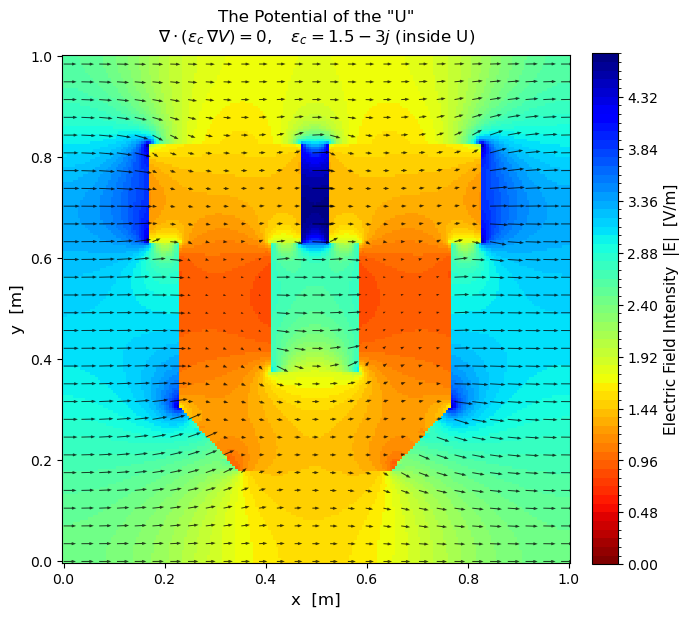

In [9]:
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

vmax = E_mag.max()*1.0#np.percentile(E_mag, 97)


levels = MaxNLocator(nbins=60).tick_values(0, vmax)
norm   = BoundaryNorm(levels, ncolors=plt.get_cmap(cmap).N, clip=True)

im = ax.pcolormesh(x, y, E_mag.T, cmap=cmap, norm=norm, shading="auto")

# im   = ax.pcolormesh(x, y, E_mag.T, cmap=cmap, shading="auto",
#                      vmin=0, vmax=vmax)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Electric Field Intensity  |E|  [V/m]", fontsize=11)
quiver_step = 7
ax.quiver(X[::quiver_step, ::quiver_step],
          Y[::quiver_step, ::quiver_step],
          Ex[::quiver_step, ::quiver_step],
          Ey[::quiver_step, ::quiver_step],
          color="k", scale=100, width=0.002, headwidth=3,
          headlength=4, alpha=0.75)

# ax.contour(X, Y, U_mask.astype(float), levels=[0.5],
#            colors="white", linewidths=1.2)

ax.set_title(
    'The Potential of the "U"\n'
    r"$\nabla\cdot(\varepsilon_c\,\nabla V)=0,"
    r"\quad \varepsilon_c=1.5-3j$ (inside U)",
    fontsize=12, pad=10,
)
ax.set_xlabel("x  [m]", fontsize=12)
ax.set_ylabel("y  [m]", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("potential_of_U.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Discussion

Several physically interesting features are visible in the solution:

**Field concentration at corners.** The electric field is strongest at the inner top corners of the U arms, where the geometry creates a re-entrant corner and the field lines must converge. This is a well-known electrostatic effect analogous to the lightning-rod principle.

**Field expulsion from the lossy dielectric.** Inside the U body the field is weaker than in the surrounding free space. The large imaginary part of $\varepsilon_c$ (high conductivity) partially screens the interior, redistributing field lines around rather than through the material.

**Uniform field far from the U.** Away from the logo the field approaches the uniform solution $V = 1 - 2x$, as expected for a parallel-plate geometry with $V = \pm 1$ V on the left and right walls.

**Role of the imaginary part.** Setting $\varepsilon_i = 0$ (real permittivity only) produces a symmetric but physically different solution — the complex part is essential for capturing the lossy dielectric response and the associated phase shift between $V_r$ and $V_i$.